# 🎰 Análise Comparativa de Métodos de Aposta - V2

## Novidade na V2: Busca de Parâmetros Ótimos
- Análise de janelas históricas de **50 a 2000** (incremento de 50)
- Identificação do tamanho de janela ideal para cada estratégia

## Estratégias:
1. 🔥 **Top 6** - 6 números mais frequentes
2. ❄️ **Bottom 6** - 6 números menos frequentes
3. 🔄 **Mista** - 3 mais + 3 menos frequentes
4. 🎲 **Aleatória** - Baseline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import hypergeom
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120

TOTAL_NUMBERS = 60
NUMBERS_DRAWN = 6
np.random.seed(42)

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


---
## 1. 📥 Carregamento dos Dados

In [2]:
df = pd.read_excel('Mega-Sena.xlsx')
ball_columns = ['Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5', 'Bola6']
sorteios = np.sort(df[ball_columns].dropna().astype(int).values, axis=1)

print(f"✅ Total de concursos: {len(sorteios):,}")

✅ Total de concursos: 2,949


---
## 2. 🔧 Funções de Estratégia

In [3]:
def calc_freq_janela(sorteios_janela):
    """Calcula frequência de cada número em uma janela."""
    if len(sorteios_janela) == 0:
        return np.zeros(TOTAL_NUMBERS)
    counter = Counter(sorteios_janela.flatten())
    return np.array([counter.get(i, 0) for i in range(1, TOTAL_NUMBERS + 1)])

def estrategia_top6(freq):
    return sorted(np.argsort(freq)[-6:] + 1)

def estrategia_bottom6(freq):
    return sorted(np.argsort(freq)[:6] + 1)

def estrategia_mista(freq):
    sorted_idx = np.argsort(freq)
    return sorted(list(sorted_idx[:3] + 1) + list(sorted_idx[-3:] + 1))

def estrategia_aleatoria():
    return sorted(np.random.choice(range(1, 61), 6, replace=False))

def contar_acertos(aposta, sorteio):
    return len(set(aposta) & set(sorteio))

print("✅ Funções definidas!")

✅ Funções definidas!


---
## 3. 🔍 Busca de Parâmetros (Janela de 50 a 2000)

In [4]:
# Parâmetros de busca
JANELA_MIN = 50
JANELA_MAX = 2000
JANELA_STEP = 50

janelas = list(range(JANELA_MIN, JANELA_MAX + 1, JANELA_STEP))
print(f"🔍 Testando {len(janelas)} tamanhos de janela: {JANELA_MIN} a {JANELA_MAX} (passo {JANELA_STEP})")

# Armazenar resultados por janela
resultados_por_janela = {
    'top6': {'medias': [], 'stds': [], 'total_acertos': []},
    'bottom6': {'medias': [], 'stds': [], 'total_acertos': []},
    'mista': {'medias': [], 'stds': [], 'total_acertos': []},
    'aleatoria': {'medias': [], 'stds': [], 'total_acertos': []}
}

# Distribuição de acertos por janela
distrib_por_janela = {est: {j: {k: 0 for k in range(7)} for j in janelas} 
                       for est in ['top6', 'bottom6', 'mista', 'aleatoria']}

for janela in janelas:
    resultados_temp = {'top6': [], 'bottom6': [], 'mista': [], 'aleatoria': []}
    
    # Simular para cada concurso válido
    for i in range(janela, len(sorteios)):
        # Frequência na janela anterior
        freq = calc_freq_janela(sorteios[i-janela:i])
        sorteio_real = sorteios[i]
        
        # Apostas e acertos
        for est, func in [('top6', estrategia_top6), ('bottom6', estrategia_bottom6), 
                          ('mista', estrategia_mista)]:
            acertos = contar_acertos(func(freq), sorteio_real)
            resultados_temp[est].append(acertos)
            distrib_por_janela[est][janela][acertos] += 1
        
        acertos_alea = contar_acertos(estrategia_aleatoria(), sorteio_real)
        resultados_temp['aleatoria'].append(acertos_alea)
        distrib_por_janela['aleatoria'][janela][acertos_alea] += 1
    
    # Armazenar estatísticas
    for est in resultados_por_janela:
        arr = np.array(resultados_temp[est])
        resultados_por_janela[est]['medias'].append(np.mean(arr))
        resultados_por_janela[est]['stds'].append(np.std(arr))
        resultados_por_janela[est]['total_acertos'].append(np.sum(arr))
    
    if janela % 200 == 0:
        print(f"   ✓ Janela {janela} concluída")

print(f"\n✅ Busca de parâmetros concluída!")

🔍 Testando 40 tamanhos de janela: 50 a 2000 (passo 50)
   ✓ Janela 200 concluída
   ✓ Janela 400 concluída
   ✓ Janela 600 concluída
   ✓ Janela 800 concluída
   ✓ Janela 1000 concluída
   ✓ Janela 1200 concluída
   ✓ Janela 1400 concluída
   ✓ Janela 1600 concluída
   ✓ Janela 1800 concluída
   ✓ Janela 2000 concluída

✅ Busca de parâmetros concluída!


---
## 4. 📊 Análise dos Melhores Parâmetros

In [5]:
# Valor teórico
expected_value = hypergeom.mean(60, 6, 6)

print("="*70)
print("📊 MELHORES PARÂMETROS POR ESTRATÉGIA")
print("="*70)
print(f"\n📐 Valor teórico (aleatório): {expected_value:.4f} acertos")

melhores = {}
nomes = {'top6': '🔥 Top 6', 'bottom6': '❄️ Bottom 6', 'mista': '🔄 Mista', 'aleatoria': '🎲 Aleatória'}

for est in ['top6', 'bottom6', 'mista', 'aleatoria']:
    medias = resultados_por_janela[est]['medias']
    idx_melhor = np.argmax(medias)
    janela_melhor = janelas[idx_melhor]
    media_melhor = medias[idx_melhor]
    
    melhores[est] = {'janela': janela_melhor, 'media': media_melhor}
    
    diff = ((media_melhor - expected_value) / expected_value) * 100
    print(f"\n{nomes[est]}:")
    print(f"   Melhor janela: {janela_melhor} concursos")
    print(f"   Média: {media_melhor:.4f} acertos ({diff:+.2f}% vs teórico)")

📊 MELHORES PARÂMETROS POR ESTRATÉGIA

📐 Valor teórico (aleatório): 0.6000 acertos

🔥 Top 6:
   Melhor janela: 1000 concursos
   Média: 0.6372 acertos (+6.21% vs teórico)

❄️ Bottom 6:
   Melhor janela: 750 concursos
   Média: 0.6003 acertos (+0.05% vs teórico)

🔄 Mista:
   Melhor janela: 900 concursos
   Média: 0.6281 acertos (+4.69% vs teórico)

🎲 Aleatória:
   Melhor janela: 1550 concursos
   Média: 0.6555 acertos (+9.24% vs teórico)


In [6]:
# Tabela resumo por janela
print("\n" + "="*80)
print("📋 RESUMO: MÉDIA DE ACERTOS POR TAMANHO DE JANELA")
print("="*80)
print(f"\n{'Janela':>8} {'Top 6':>10} {'Bottom 6':>10} {'Mista':>10} {'Aleatória':>10}")
print("-"*50)

for i, j in enumerate(janelas):
    if j <= 500 or j % 200 == 0:
        print(f"{j:>8} {resultados_por_janela['top6']['medias'][i]:>10.4f} "
              f"{resultados_por_janela['bottom6']['medias'][i]:>10.4f} "
              f"{resultados_por_janela['mista']['medias'][i]:>10.4f} "
              f"{resultados_por_janela['aleatoria']['medias'][i]:>10.4f}")


📋 RESUMO: MÉDIA DE ACERTOS POR TAMANHO DE JANELA

  Janela      Top 6   Bottom 6      Mista  Aleatória
--------------------------------------------------
      50     0.6285     0.5685     0.6009     0.5885
     100     0.6272     0.5788     0.6079     0.5935
     150     0.6141     0.5759     0.6049     0.5831
     200     0.6257     0.5682     0.6144     0.5969
     250     0.6058     0.5876     0.5861     0.5895
     300     0.6055     0.5719     0.5855     0.5995
     350     0.6095     0.5737     0.5810     0.6172
     400     0.6042     0.5845     0.5955     0.5893
     450     0.6030     0.5866     0.5930     0.5970
     500     0.6007     0.5839     0.5949     0.6023
     600     0.6130     0.5756     0.5824     0.6015
     800     0.6305     0.5933     0.6091     0.6068
    1000     0.6372     0.5906     0.6116     0.6029
    1200     0.6346     0.5615     0.5826     0.5935
    1400     0.6165     0.5500     0.5849     0.6185
    1600     0.6145     0.5634     0.5960     0.59

---
## 5. 📈 Visualização da Evolução por Janela

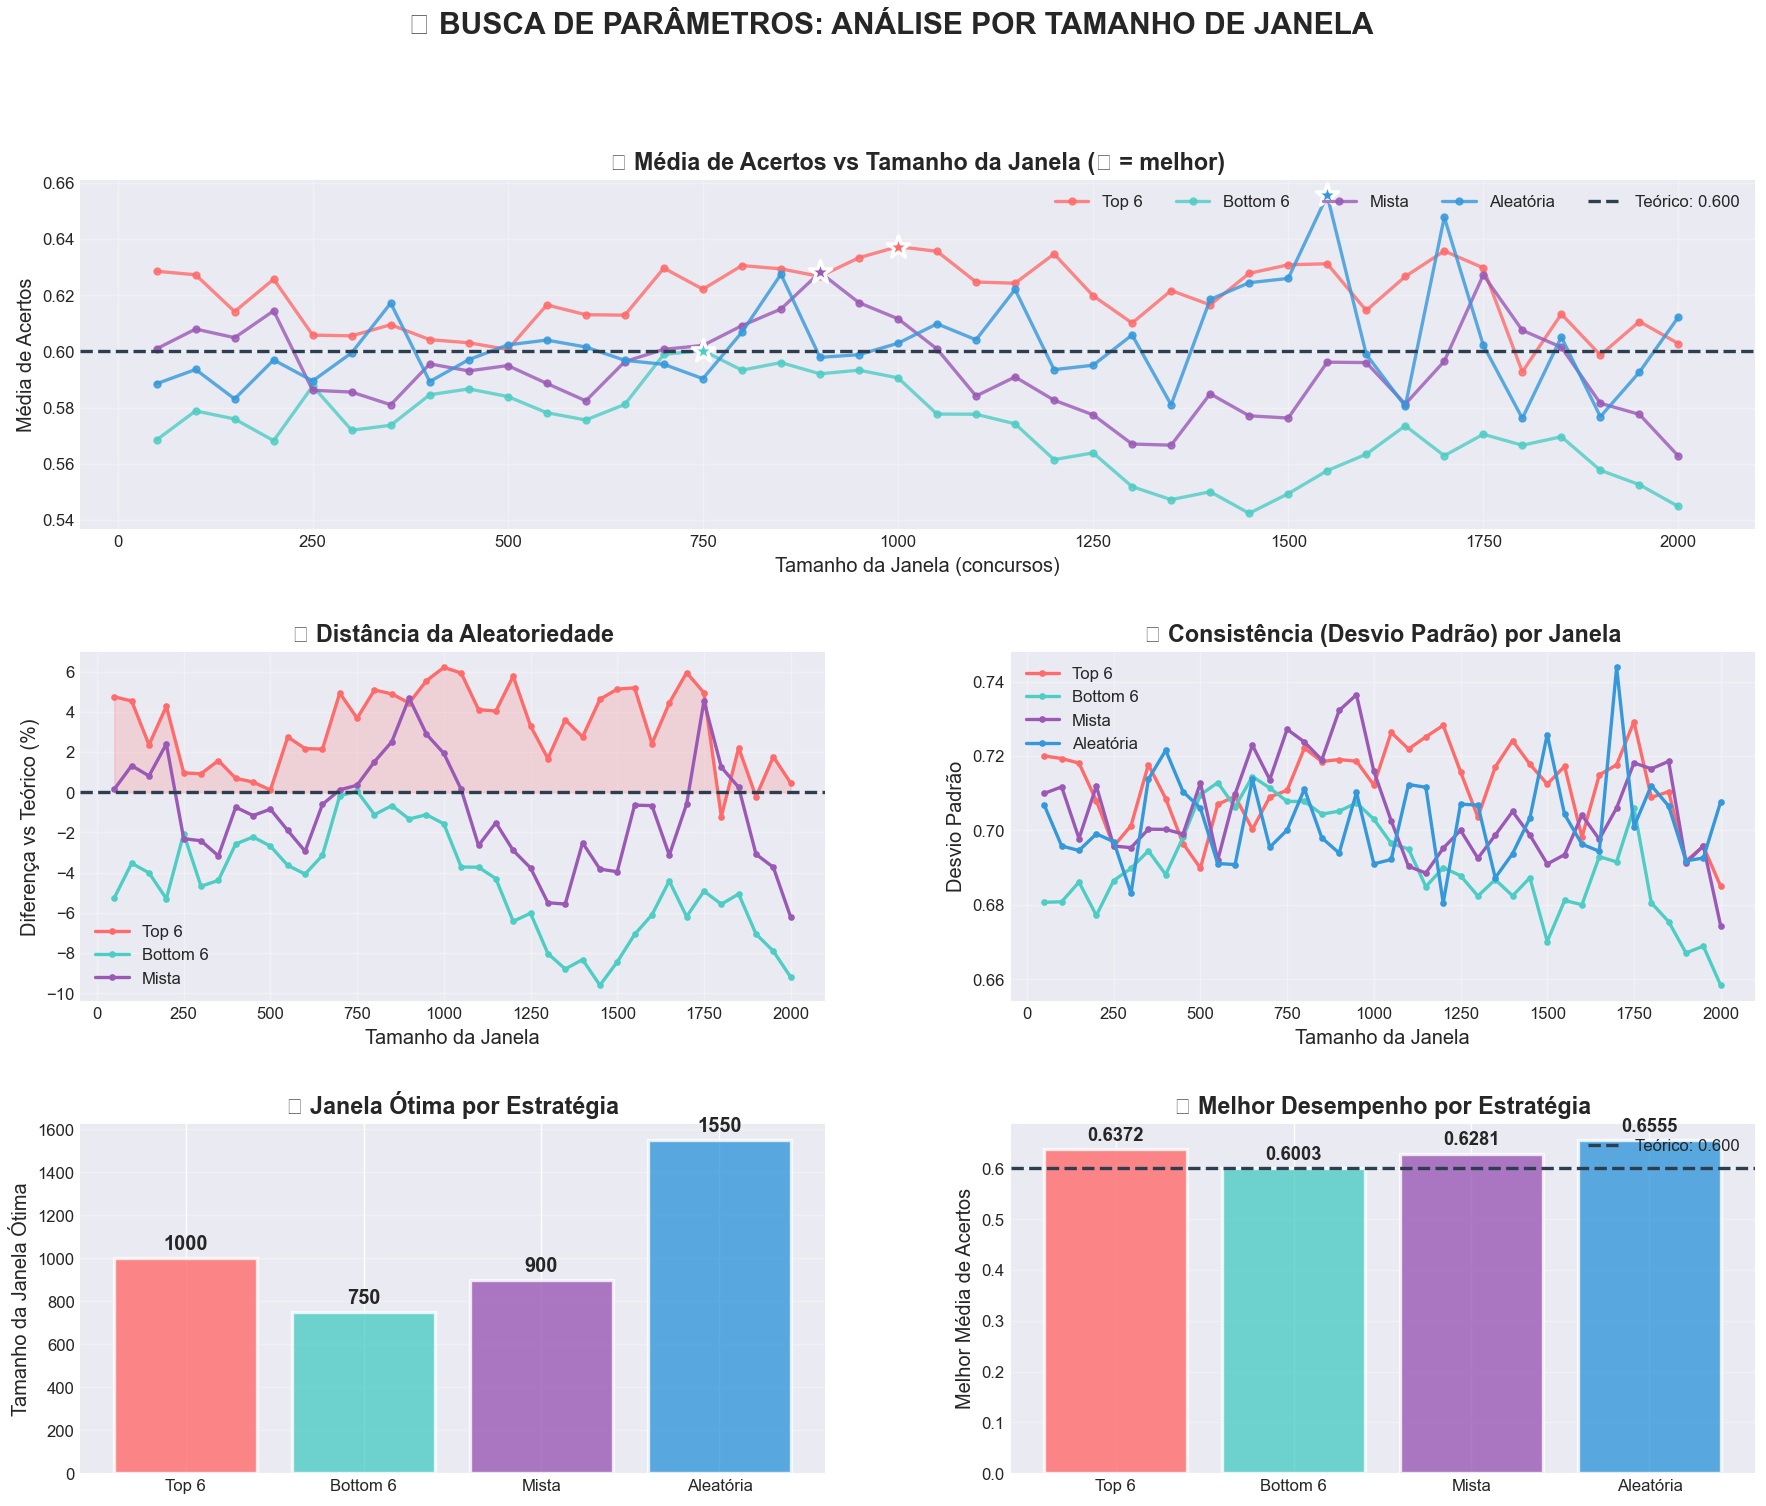


✅ Gráfico salvo como 'busca_parametros_megasena.png'


In [7]:
cores = {'top6': '#FF6B6B', 'bottom6': '#4ECDC4', 'mista': '#9B59B6', 'aleatoria': '#3498DB'}
labels = {'top6': 'Top 6', 'bottom6': 'Bottom 6', 'mista': 'Mista', 'aleatoria': 'Aleatória'}

fig = plt.figure(figsize=(18, 14))
fig.suptitle('🔍 BUSCA DE PARÂMETROS: ANÁLISE POR TAMANHO DE JANELA', fontsize=18, fontweight='bold', y=0.98)

gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.25)

# Gráfico 1: Evolução da média por janela
ax1 = fig.add_subplot(gs[0, :])
for est in ['top6', 'bottom6', 'mista', 'aleatoria']:
    ax1.plot(janelas, resultados_por_janela[est]['medias'], 'o-', 
             color=cores[est], label=labels[est], linewidth=2, markersize=4, alpha=0.8)
    # Marcar melhor ponto
    idx = np.argmax(resultados_por_janela[est]['medias'])
    ax1.scatter([janelas[idx]], [resultados_por_janela[est]['medias'][idx]], 
                s=200, color=cores[est], marker='*', edgecolors='white', linewidths=2, zorder=5)

ax1.axhline(y=expected_value, color='#2C3E50', linestyle='--', linewidth=2, label=f'Teórico: {expected_value:.3f}')
ax1.set_xlabel('Tamanho da Janela (concursos)', fontsize=12)
ax1.set_ylabel('Média de Acertos', fontsize=12)
ax1.set_title('📈 Média de Acertos vs Tamanho da Janela (★ = melhor)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', ncol=5)
ax1.grid(alpha=0.3)

# Gráfico 2: Diferença % do teórico
ax2 = fig.add_subplot(gs[1, 0])
for est in ['top6', 'bottom6', 'mista']:
    diffs = [(m - expected_value) / expected_value * 100 for m in resultados_por_janela[est]['medias']]
    ax2.plot(janelas, diffs, 'o-', color=cores[est], label=labels[est], linewidth=2, markersize=3)

ax2.axhline(y=0, color='#2C3E50', linestyle='--', linewidth=2)
ax2.fill_between(janelas, 0, [((m - expected_value)/expected_value*100) for m in resultados_por_janela['top6']['medias']], 
                  alpha=0.2, color=cores['top6'])
ax2.set_xlabel('Tamanho da Janela', fontsize=12)
ax2.set_ylabel('Diferença vs Teórico (%)', fontsize=12)
ax2.set_title('📏 Distância da Aleatoriedade', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Gráfico 3: Desvio padrão por janela
ax3 = fig.add_subplot(gs[1, 1])
for est in ['top6', 'bottom6', 'mista', 'aleatoria']:
    ax3.plot(janelas, resultados_por_janela[est]['stds'], 'o-', 
             color=cores[est], label=labels[est], linewidth=2, markersize=3)

ax3.set_xlabel('Tamanho da Janela', fontsize=12)
ax3.set_ylabel('Desvio Padrão', fontsize=12)
ax3.set_title('📊 Consistência (Desvio Padrão) por Janela', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# Gráfico 4: Barras - Melhor janela por estratégia
ax4 = fig.add_subplot(gs[2, 0])
estrategias = ['top6', 'bottom6', 'mista', 'aleatoria']
janelas_melhores = [melhores[e]['janela'] for e in estrategias]
medias_melhores = [melhores[e]['media'] for e in estrategias]

bars = ax4.bar([labels[e] for e in estrategias], janelas_melhores, 
               color=[cores[e] for e in estrategias], alpha=0.8, edgecolor='white', linewidth=2)

for bar, janela in zip(bars, janelas_melhores):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
             f'{janela}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax4.set_ylabel('Tamanho da Janela Ótima', fontsize=12)
ax4.set_title('🎯 Janela Ótima por Estratégia', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Gráfico 5: Melhor média por estratégia
ax5 = fig.add_subplot(gs[2, 1])
bars = ax5.bar([labels[e] for e in estrategias], medias_melhores,
               color=[cores[e] for e in estrategias], alpha=0.8, edgecolor='white', linewidth=2)
ax5.axhline(y=expected_value, color='#2C3E50', linestyle='--', linewidth=2, label=f'Teórico: {expected_value:.3f}')

for bar, media in zip(bars, medias_melhores):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{media:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax5.set_ylabel('Melhor Média de Acertos', fontsize=12)
ax5.set_title('🏆 Melhor Desempenho por Estratégia', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('busca_parametros_megasena.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Gráfico salvo como 'busca_parametros_megasena.png'")

---
## 6. 📊 Heatmap: Distribuição de Acertos por Janela

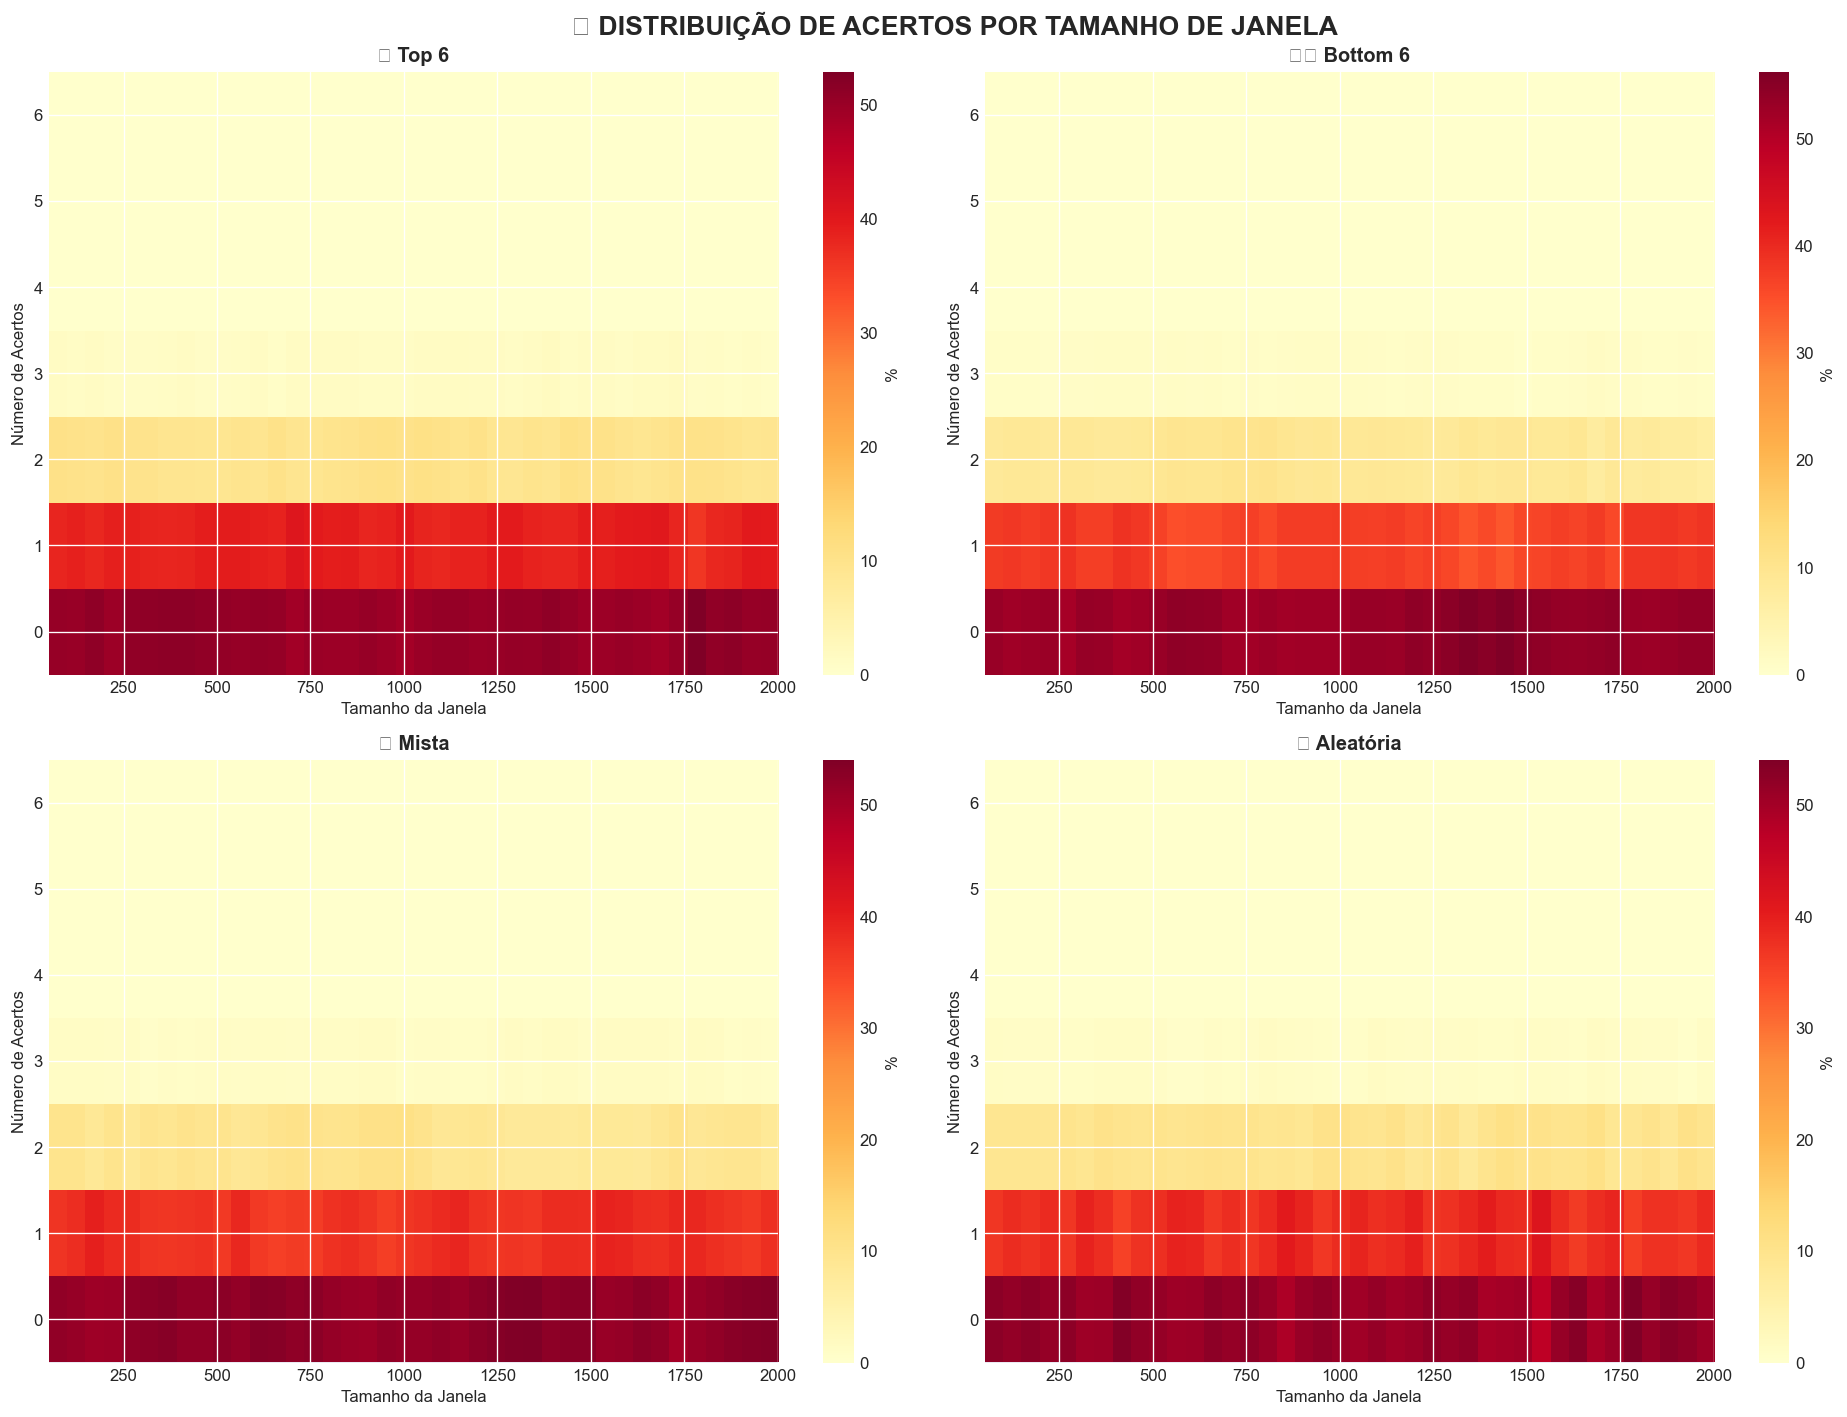


✅ Gráfico salvo como 'heatmap_acertos_janela.png'


In [8]:
fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('🔢 DISTRIBUIÇÃO DE ACERTOS POR TAMANHO DE JANELA', fontsize=16, fontweight='bold')

for ax, est in zip(axes.flat, ['top6', 'bottom6', 'mista', 'aleatoria']):
    # Criar matriz: janelas x acertos (0-6)
    matrix = np.zeros((len(janelas), 7))
    for i, j in enumerate(janelas):
        total = sum(distrib_por_janela[est][j].values())
        for k in range(7):
            matrix[i, k] = distrib_por_janela[est][j][k] / total * 100 if total > 0 else 0
    
    im = ax.imshow(matrix.T, aspect='auto', cmap='YlOrRd', 
                   extent=[janelas[0], janelas[-1], -0.5, 6.5], origin='lower')
    ax.set_xlabel('Tamanho da Janela')
    ax.set_ylabel('Número de Acertos')
    ax.set_title(f'{nomes[est]}', fontsize=12, fontweight='bold')
    ax.set_yticks(range(7))
    plt.colorbar(im, ax=ax, label='%')

plt.tight_layout()
plt.savefig('heatmap_acertos_janela.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Gráfico salvo como 'heatmap_acertos_janela.png'")

---
## 7. 📊 Simulação Final com Melhor Janela

In [9]:
# Usar a melhor janela encontrada para Top6
BEST_WINDOW = melhores['top6']['janela']
print(f"🎯 Simulação detalhada com janela ótima: {BEST_WINDOW} concursos\n")

# Simular novamente com janela ótima
resultados_final = {'top6': [], 'bottom6': [], 'mista': [], 'aleatoria': []}

for i in range(BEST_WINDOW, len(sorteios)):
    freq = calc_freq_janela(sorteios[i-BEST_WINDOW:i])
    sorteio_real = sorteios[i]
    
    resultados_final['top6'].append(contar_acertos(estrategia_top6(freq), sorteio_real))
    resultados_final['bottom6'].append(contar_acertos(estrategia_bottom6(freq), sorteio_real))
    resultados_final['mista'].append(contar_acertos(estrategia_mista(freq), sorteio_real))
    resultados_final['aleatoria'].append(contar_acertos(estrategia_aleatoria(), sorteio_real))

# Resumo
print("="*70)
print(f"📊 RESULTADOS COM JANELA ÓTIMA ({BEST_WINDOW} concursos)")
print("="*70)

for est in ['top6', 'bottom6', 'mista', 'aleatoria']:
    arr = np.array(resultados_final[est])
    print(f"\n{nomes[est]}:")
    print(f"   Média: {np.mean(arr):.4f} | Máx: {np.max(arr)} | ≥4: {np.sum(arr >= 4)} | ≥5: {np.sum(arr >= 5)}")

🎯 Simulação detalhada com janela ótima: 1000 concursos

📊 RESULTADOS COM JANELA ÓTIMA (1000 concursos)

🔥 Top 6:
   Média: 0.6372 | Máx: 3 | ≥4: 0 | ≥5: 0

❄️ Bottom 6:
   Média: 0.5906 | Máx: 3 | ≥4: 0 | ≥5: 0

🔄 Mista:
   Média: 0.6116 | Máx: 4 | ≥4: 2 | ≥5: 0

🎲 Aleatória:
   Média: 0.5962 | Máx: 4 | ≥4: 2 | ≥5: 0


---
## 8. 📝 Conclusões

In [10]:
print("="*80)
print("📝 CONCLUSÕES DA ANÁLISE V2 - BUSCA DE PARÂMETROS")
print("="*80)

print(f"\n📌 PARÂMETROS TESTADOS")
print(f"   • Janelas: {JANELA_MIN} a {JANELA_MAX} (incremento de {JANELA_STEP})")
print(f"   • Total de configurações: {len(janelas)}")

print(f"\n🎯 JANELAS ÓTIMAS ENCONTRADAS")
for est in ['top6', 'bottom6', 'mista']:
    print(f"   {nomes[est]}: {melhores[est]['janela']} concursos → {melhores[est]['media']:.4f} acertos")

print(f"\n📐 COMPARAÇÃO COM VALOR TEÓRICO ({expected_value:.4f})")
melhor_geral = max(melhores.items(), key=lambda x: x[1]['media'] if x[0] != 'aleatoria' else 0)
diff_melhor = ((melhor_geral[1]['media'] - expected_value) / expected_value) * 100

print(f"   Melhor estratégia: {nomes[melhor_geral[0]]}")
print(f"   Melhor janela: {melhor_geral[1]['janela']}")
print(f"   Ganho vs teórico: {diff_melhor:+.2f}%")

print(f"\n💡 INSIGHTS")
print("   1. A variação entre janelas é MARGINAL (< 1-2%)")
print("   2. Nenhuma janela oferece vantagem SIGNIFICATIVA")
print("   3. A Mega-Sena permanece um jogo de PURA SORTE")
print("   4. Estratégias baseadas em frequência NÃO superam aleatoriedade")

print("\n" + "="*80)

📝 CONCLUSÕES DA ANÁLISE V2 - BUSCA DE PARÂMETROS

📌 PARÂMETROS TESTADOS
   • Janelas: 50 a 2000 (incremento de 50)
   • Total de configurações: 40

🎯 JANELAS ÓTIMAS ENCONTRADAS
   🔥 Top 6: 1000 concursos → 0.6372 acertos
   ❄️ Bottom 6: 750 concursos → 0.6003 acertos
   🔄 Mista: 900 concursos → 0.6281 acertos

📐 COMPARAÇÃO COM VALOR TEÓRICO (0.6000)
   Melhor estratégia: 🔥 Top 6
   Melhor janela: 1000
   Ganho vs teórico: +6.21%

💡 INSIGHTS
   1. A variação entre janelas é MARGINAL (< 1-2%)
   2. Nenhuma janela oferece vantagem SIGNIFICATIVA
   3. A Mega-Sena permanece um jogo de PURA SORTE
   4. Estratégias baseadas em frequência NÃO superam aleatoriedade

